In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FILE = "/ofo-share/repos/david/tree-detection-parameterization/data/scores.csv"

DATASETS_TO_EXCLUDE = set(
    [
        "0128_000018_000016",
        "0137_000208_000210",
        "0157_000204_000205",
        "0162_000211_000220",
        "0163_000211_000220",
        "0167_000319_000318",
        "0172_001270_001271",
        "0174_001270_001271",
        "0191_001211_001210",
        "0194_001213_001212",
        "0208_000112_000310",
        "0211_000112_000310",
    ]
)

data = pd.read_csv(FILE)
# Temporary: parse sigma, b, c from param_combo column (format: sigma_{sigma}__b_{b}_c_{c})
data["sigma"] = data.param_combo.str.extract(r"sigma_([\d.]+)__").astype(float)
data["b"] = data.param_combo.str.extract(r"_b_([\d.]+)_c_").astype(float)
data["c"] = data.param_combo.str.extract(r"_c_([\d.]+)$").astype(float)

In [38]:
data = data[~data.dataset.isin(DATASETS_TO_EXCLUDE)]

In [39]:
data_without_dataset = data.drop(columns="dataset")
mean_results = data_without_dataset.groupby("param_combo").mean()
mean_results = mean_results.sort_values("F1")
mean_results

,F1,precision,recall,n_core_field,n_core_drone,n_field_matched,n_drone_matched,sigma,b,c
param_combo,,,,,,,,,,
sigma_1.5__b_0.01_c_0,0.010960,0.005570,0.766203,128.223022,19048.359712,97.093525,87.949640,1.50,0.01,0.00
sigma_1.0__b_0.01_c_0,0.014101,0.007177,0.820863,128.223022,16230.705036,103.064748,95.251799,1.00,0.01,0.00
sigma_0.5__b_0.01_c_0,0.018345,0.009348,0.867668,128.223022,13459.028777,108.762590,101.892086,0.50,0.01,0.00
sigma_0.25__b_0.01_c_0,0.021799,0.011140,0.895263,128.223022,12103.474820,112.611511,106.194245,0.25,0.01,0.00
sigma_1.5__b_0.05_c_0.5,0.607515,0.900540,0.475600,128.223022,63.640288,58.510791,56.287770,1.50,0.05,0.50
sigma_1.5__b_0.04_c_0.5,0.613513,0.899062,0.483009,128.223022,64.971223,59.568345,57.352518,1.50,0.04,0.50
sigma_1.5__b_0.05_c_0.25,0.614103,0.899321,0.483560,128.223022,65.014388,59.625899,57.381295,1.50,0.05,0.25
sigma_1.5__b_0.03_c_0.5,0.621026,0.897130,0.492331,128.223022,66.172662,60.474820,58.273381,1.50,0.03,0.50
sigma_1.5__b_0.05_c_0,0.621286,0.896370,0.492670,128.223022,66.244604,60.568345,58.316547,1.50,0.05,0.00


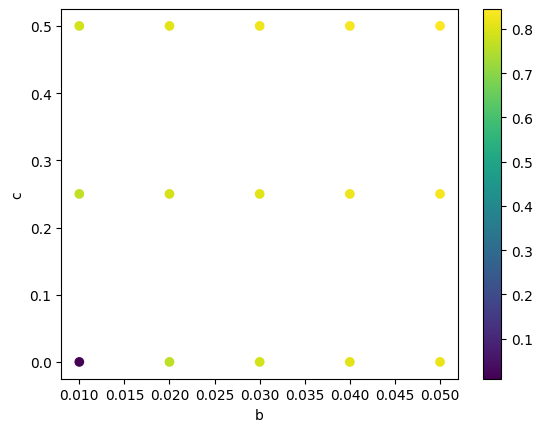

,F1,precision,recall,n_core_field,n_core_drone,n_field_matched,n_drone_matched,sigma,b,c
param_combo,,,,,,,,,,
sigma_0.5__b_0.01_c_0,0.018345,0.009348,0.867668,128.223022,13459.028777,108.762590,101.892086,0.5,0.01,0.00
sigma_0.5__b_0.05_c_0.5,0.701738,0.845006,0.614435,128.223022,87.834532,72.776978,71.525180,0.5,0.05,0.50
sigma_0.5__b_0.04_c_0.5,0.710693,0.835023,0.632304,128.223022,91.690647,74.906475,73.625899,0.5,0.04,0.50
sigma_0.5__b_0.05_c_0.25,0.711647,0.833686,0.634450,128.223022,92.050360,75.115108,73.827338,0.5,0.05,0.25
sigma_0.5__b_0.03_c_0.5,0.717650,0.823090,0.649178,128.223022,95.971223,76.964029,75.733813,0.5,0.03,0.50
sigma_0.5__b_0.04_c_0.25,0.718269,0.822516,0.650644,128.223022,96.230216,77.230216,75.949640,0.5,0.04,0.25
sigma_0.5__b_0.05_c_0,0.718271,0.818343,0.653191,128.223022,96.697842,77.460432,76.136691,0.5,0.05,0.00
sigma_0.5__b_0.01_c_0.25,0.719127,0.767367,0.690493,128.223022,112.640288,82.395683,81.064748,0.5,0.01,0.25
sigma_0.5__b_0.01_c_0.5,0.720611,0.788284,0.676572,128.223022,106.474820,80.705036,79.431655,0.5,0.01,0.50


In [40]:
mean_results_blur = mean_results.query("sigma==0.5")
mean_results_blur
#plt.scatter(mean_results_blur["b"], mean_results_blur["c"], c=mean_results_blur["F1"], vmin=0.685493, vmax=0.716284)
plt.scatter(mean_results_blur["b"], mean_results_blur["c"], c=mean_results_blur["precision"])
plt.colorbar()
plt.xlabel("b")
plt.ylabel("c")
plt.show()
display(mean_results_blur)

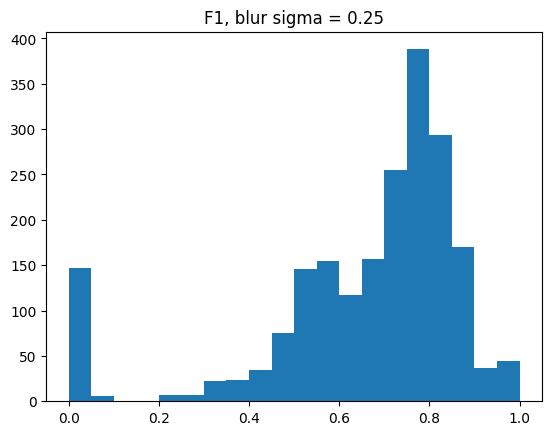

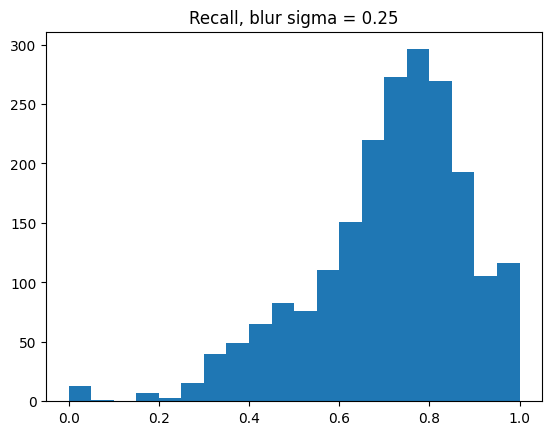

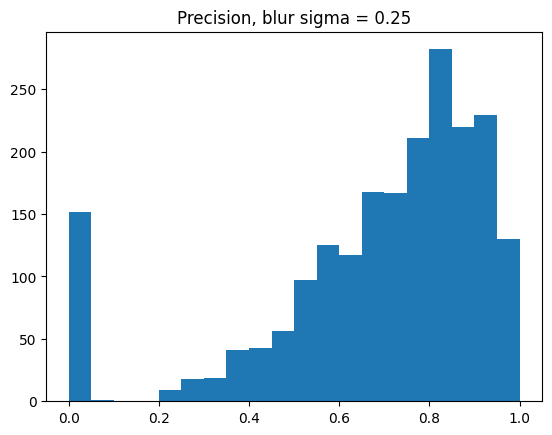

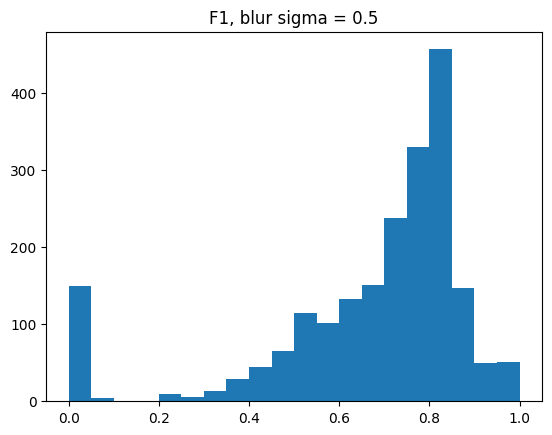

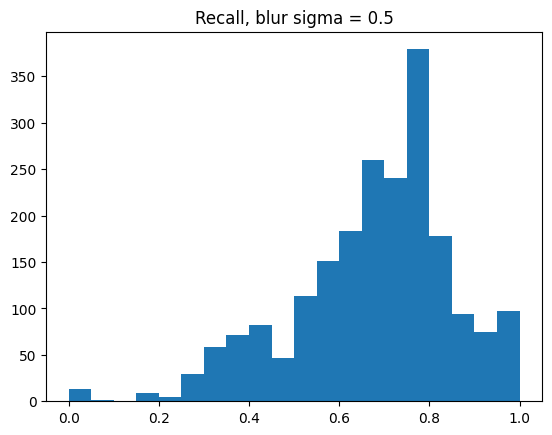

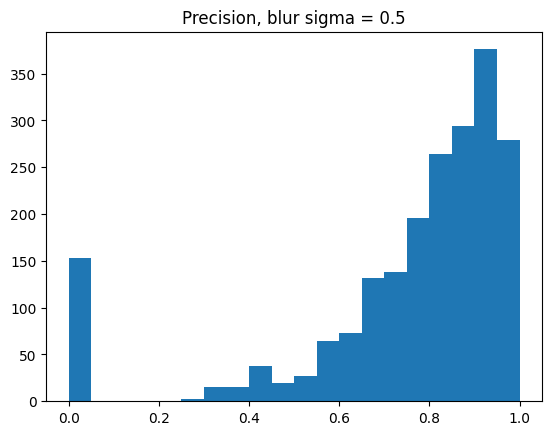

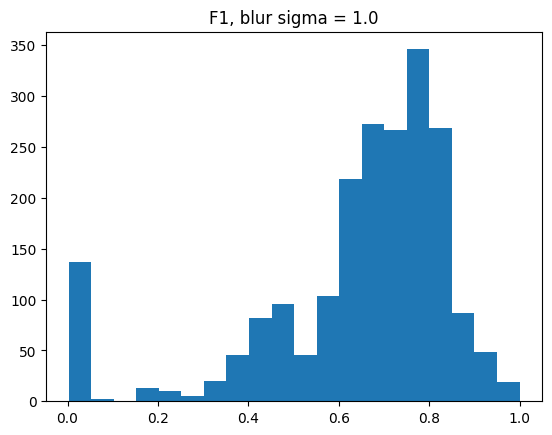

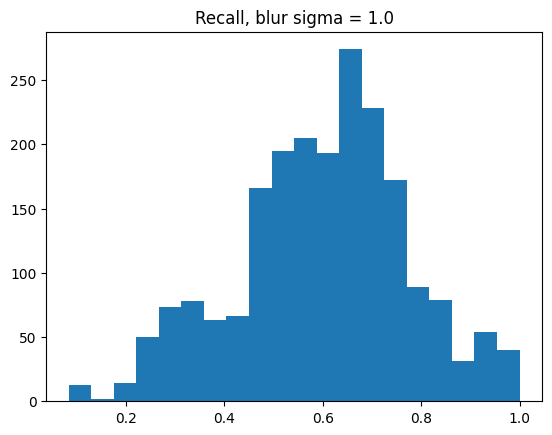

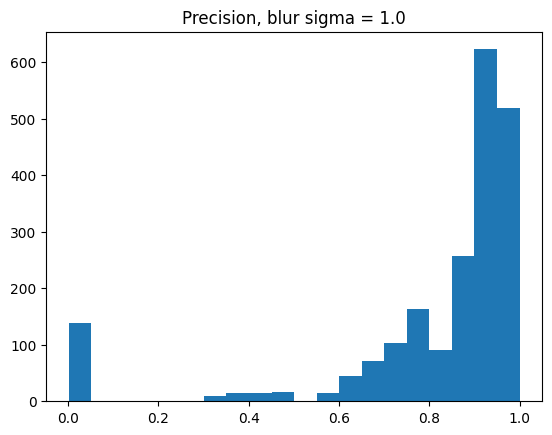

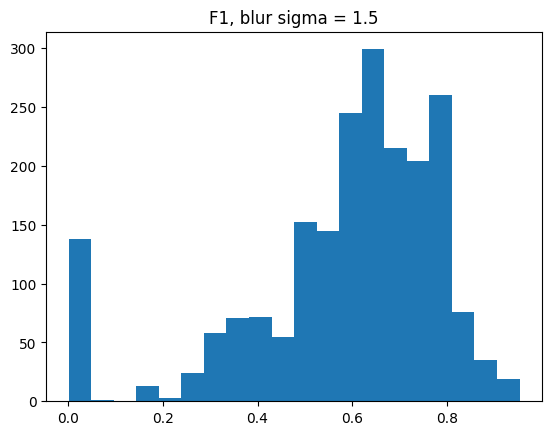

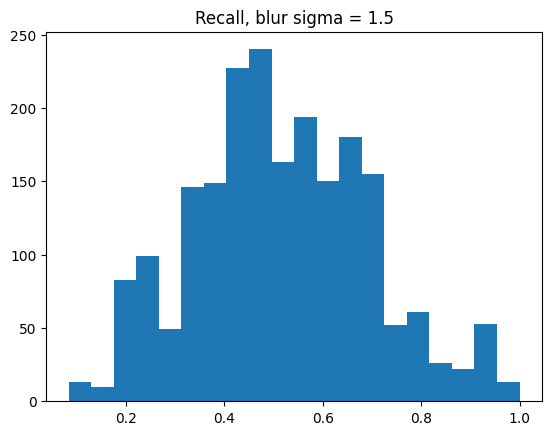

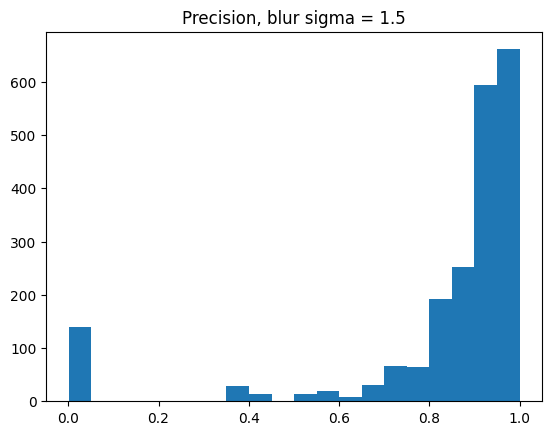

In [41]:
RASTER_BLUR_SIGMAS = [0.25, 0.5, 1.0, 1.5]
for sigma in RASTER_BLUR_SIGMAS:
    subset_data = data.query("sigma == @sigma")
    plt.hist(subset_data["F1"], bins=20)
    plt.title(f"F1, blur sigma = {sigma}")
    plt.show()
    plt.close()

    plt.hist(subset_data["recall"], bins=20)
    plt.title(f"Recall, blur sigma = {sigma}")
    plt.show()
    plt.close()

    plt.hist(subset_data["precision"], bins=20)
    plt.title(f"Precision, blur sigma = {sigma}")
    plt.show()
    plt.close()